C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading txs_features...
  shape: (203769, 184)
  columns: ['txId', 'Time step', 'Local_feature_1', 'Local_feature_2', 'Local_feature_3', 'Local_feature_4', 'Local_feature_5', 'Local_feature_6', 'Local_feature_7', 'Local_feature_8'] ...

Loading txs_classes...
  shape: (203769, 2)
  columns: ['txId', 'class']
  class unique: [3 2 1]

Loading txs_edgelist...
  shape: (234355, 2)
  columns: ['txId1', 'txId2']

=== Features overview ===
    txId  Time step  Local_feature_1  Local_feature_2  Local_feature_3  \
0   3321          1        -0.169615        -0.184668        -1.201369   
1  11108          1        -0.137586        -0.184668        -1.201369   
2  51816          1        -0.170103        -0.184668        -1.201369   
3  68869          1        -0.114267        -0.184668        -1.201369   
4  89273          1         5.202107        -0.210553        -1.756361   

   Local_feature_4  Local_feature_5  Local_feature_6  Local_feature_7  \
0        -0.121970        -0.043875        -0

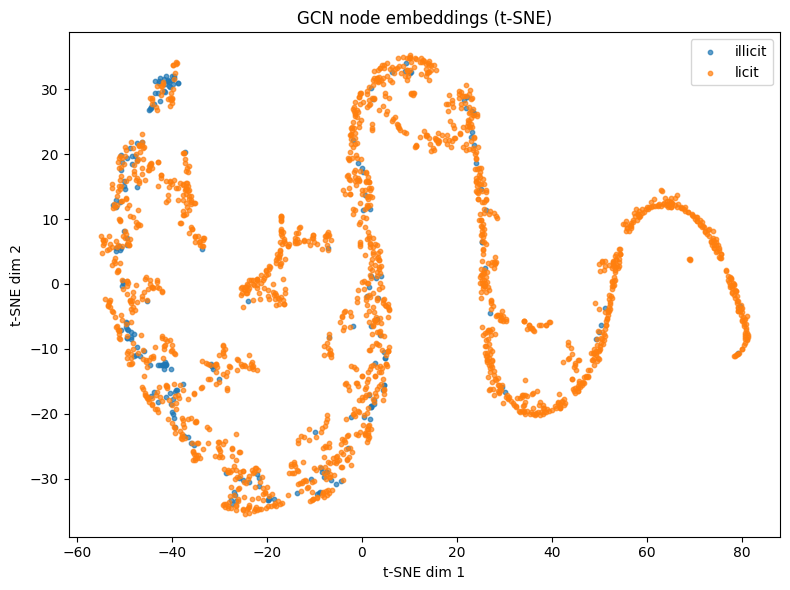

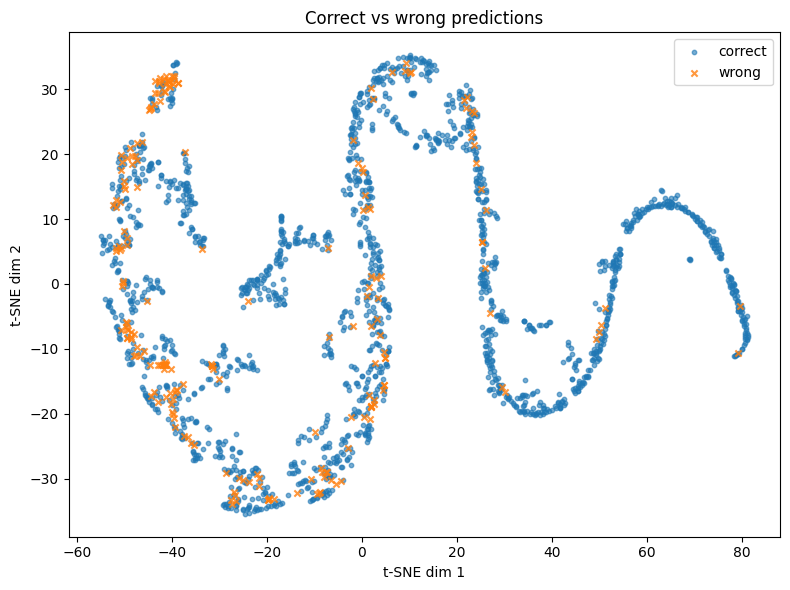

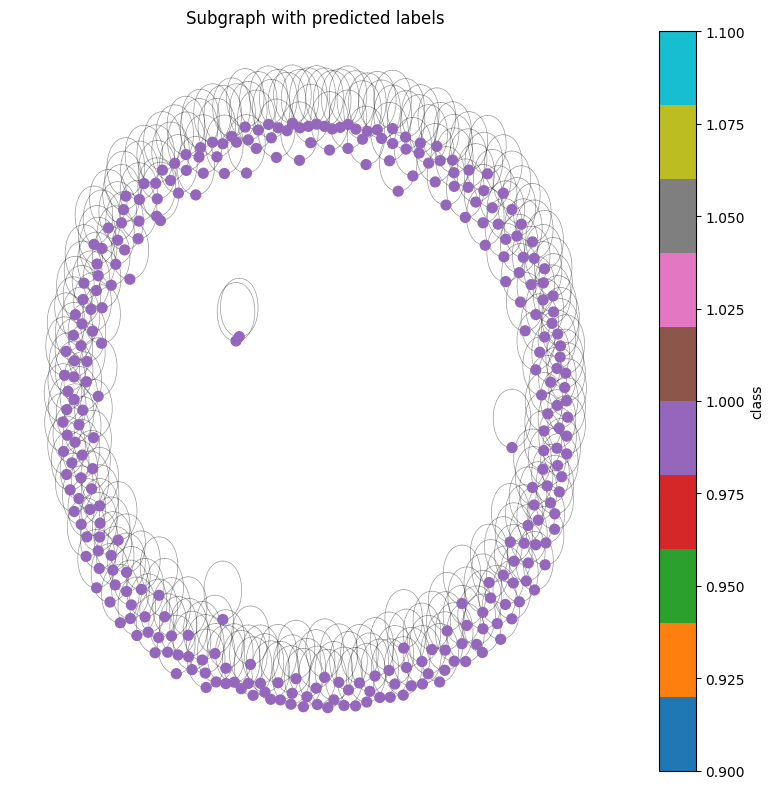

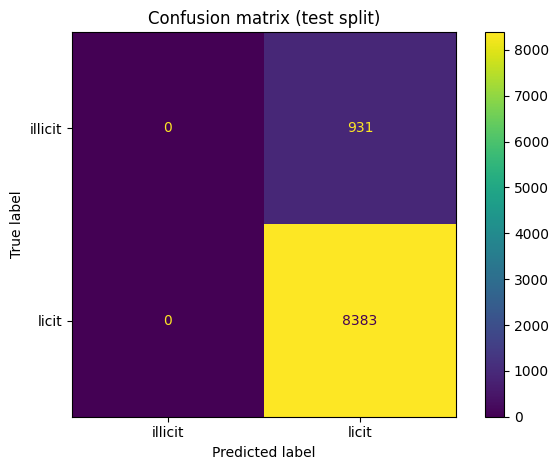


=== Classification Report (test only) ===
              precision    recall  f1-score   support

     illicit       0.00      0.00      0.00       931
       licit       0.90      1.00      0.95      8383

    accuracy                           0.90      9314
   macro avg       0.45      0.50      0.47      9314
weighted avg       0.81      0.90      0.85      9314


Done.


In [1]:
"""
Elliptic++ っぽいトランザクショングラフに
GNN（GCN）を適用して可視化する完全版スクリプト。

修正版ポイント
1) txs_features / txs_classes / txs_edgelist を pandas で読み込み
2) PyTorch Geometric の Data へ変換
3) class=3 を unknown とみなし、学習対象から除外
4) NaN / Inf を除去して GCN でノード分類
5) t-SNE で埋め込み可視化
6) サブグラフ可視化
7) テストデータのみで混同行列を表示
"""

import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx, to_undirected, add_self_loops
from torch_geometric.nn import GCNConv

from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


warnings.filterwarnings("ignore")


# ====== ファイルパス ======
TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"


# ==========================
# ユーティリティ
# ==========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def check_files():
    for path in [TXS_FEATURES, TXS_CLASSES, TXS_EDGES]:
        if not Path(path).exists():
            raise FileNotFoundError(f"ファイルが見つかりません: {path}")


def split_labeled_nodes(
    labeled_indices: torch.Tensor,
    num_nodes: int,
    train_ratio: float = 0.6,
    val_ratio: float = 0.2
):
    """
    ラベル付きノードだけを train / val / test に分割
    """
    assert train_ratio + val_ratio < 1.0

    perm = labeled_indices[torch.randperm(labeled_indices.numel())]
    n_total = perm.numel()

    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    return train_mask, val_mask, test_mask


# ==========================
# データ読み込み
# ==========================
def load_raw_data():
    print("Loading txs_features...")
    df_features = pd.read_csv(TXS_FEATURES)
    print("  shape:", df_features.shape)
    print("  columns:", list(df_features.columns[:10]), "...")

    print("\nLoading txs_classes...")
    df_classes = pd.read_csv(TXS_CLASSES)
    print("  shape:", df_classes.shape)
    print("  columns:", list(df_classes.columns))
    if "class" in df_classes.columns:
        print("  class unique:", df_classes["class"].unique())

    print("\nLoading txs_edgelist...")
    df_edges = pd.read_csv(TXS_EDGES)
    print("  shape:", df_edges.shape)
    print("  columns:", list(df_edges.columns))

    print("\n=== Features overview ===")
    print(df_features.head())
    print("missing values (total):", int(df_features.isnull().sum().sum()))

    print("\n=== Features: missing per column (top 10) ===")
    print(df_features.isnull().sum().sort_values(ascending=False).head(10))

    print("\n=== Classes overview ===")
    if "class" in df_classes.columns:
        print(df_classes["class"].value_counts(dropna=False))
    else:
        print("WARNING: 'class' column not found in classes file.")

    print("\n=== Edges overview ===")
    print(df_edges.head())
    print("duplicate edges:", int(df_edges.duplicated().sum()))

    return df_features, df_classes, df_edges


# ==========================
# PyG Data 構築
# ==========================
def build_pyg_data(
    df_features: pd.DataFrame,
    df_classes: pd.DataFrame,
    df_edges: pd.DataFrame
):
    """
    pandas DataFrame から PyG の Data を作る。

    前提:
    - df_features の1列目をノードIDとみなす
    - df_classes の 'class' は Elliptic系を想定して
        1 -> illicit
        2 -> licit
        3 -> unknown
      とし、3 は学習対象から除外する
    - df_edges の最初の2列を (src, dst) とみなす
    """
    id_col_feat = df_features.columns[0]
    print(f"\n[build_pyg_data] using '{id_col_feat}' as node id column.")

    # ---- 特徴量行列 X ----
    feature_cols = [c for c in df_features.columns if c != id_col_feat]
    x_df = df_features[feature_cols].copy()

    # 数値化
    x_df = x_df.apply(pd.to_numeric, errors="coerce")

    nan_total_before = int(x_df.isna().sum().sum())
    inf_total_before = int(np.isinf(x_df.to_numpy(dtype=np.float64)).sum())

    print("[build_pyg_data] NaN in features before fill:", nan_total_before)
    print("[build_pyg_data] Inf in features before replace:", inf_total_before)

    # Inf -> NaN -> 0
    x_df = x_df.replace([np.inf, -np.inf], np.nan)
    x_df = x_df.fillna(0.0)

    x_np = x_df.to_numpy(dtype=np.float32)
    x_np = np.clip(x_np, -1e6, 1e6)

    x = torch.tensor(x_np, dtype=torch.float)
    num_nodes = x.size(0)

    print("[build_pyg_data] x shape:", tuple(x.shape))
    print("[build_pyg_data] torch.isnan(x).any():", torch.isnan(x).any().item())
    print("[build_pyg_data] torch.isinf(x).any():", torch.isinf(x).any().item())

    # ---- ノードID -> index ----
    node_ids = df_features[id_col_feat].astype(int).values
    id2idx = {int(nid): i for i, nid in enumerate(node_ids)}

    # ---- クラスラベル y ----
    if "class" not in df_classes.columns:
        raise ValueError("df_classes に 'class' 列がありません。")

    if id_col_feat in df_classes.columns:
        id_col_cls = id_col_feat
    else:
        id_col_cls = df_classes.columns[0]
        print(f"[build_pyg_data] WARNING: using '{id_col_cls}' as class id column.")

    cls_series = (
        df_classes
        .set_index(id_col_cls)["class"]
        .reindex(node_ids)
    )

    # Elliptic系の慣例
    # 1 -> 0
    # 2 -> 1
    # 3 -> -1 (unknown)
    label_map = {1: 0, 2: 1, 3: -1}
    y_np = cls_series.map(label_map).fillna(-1).to_numpy(dtype=np.int64)
    y = torch.tensor(y_np, dtype=torch.long)

    labeled_mask = y >= 0
    labeled_indices = torch.where(labeled_mask)[0]

    print("[build_pyg_data] labeled nodes:", int(labeled_mask.sum()), "/", num_nodes)
    print("[build_pyg_data] y value counts:")
    print(pd.Series(y_np).value_counts(dropna=False).sort_index())

    # クラス名
    classes = ["illicit", "licit"]

    # ---- エッジ ----
    edge_cols = list(df_edges.columns[:2])

    src_raw = df_edges[edge_cols[0]].values
    dst_raw = df_edges[edge_cols[1]].values

    src_idx = []
    dst_idx = []
    missing_edges = 0

    for u, v in zip(src_raw, dst_raw):
        u = int(u)
        v = int(v)
        if u in id2idx and v in id2idx:
            src_idx.append(id2idx[u])
            dst_idx.append(id2idx[v])
        else:
            missing_edges += 1

    edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)

    # GCN向けに無向化 + 自己ループ追加
    edge_index = to_undirected(edge_index, num_nodes=num_nodes)
    edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)

    print("[build_pyg_data] edge_index shape:", tuple(edge_index.shape))
    print("[build_pyg_data] skipped edges with unknown nodes:", missing_edges)

    # ---- Data オブジェクト ----
    data = Data(x=x, edge_index=edge_index, y=y)

    # ラベル付きノードだけで分割
    train_mask, val_mask, test_mask = split_labeled_nodes(
        labeled_indices=labeled_indices,
        num_nodes=num_nodes,
        train_ratio=0.6,
        val_ratio=0.2
    )

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data.labeled_mask = labeled_mask

    print("[build_pyg_data] train/val/test labeled counts:",
          int(data.train_mask.sum()),
          int(data.val_mask.sum()),
          int(data.test_mask.sum()))

    return data, classes


# ==========================
# GCN モデル
# ==========================
class GCN(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        dropout: float = 0.5
    ):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        embeddings = x
        logits = self.lin(x)

        if return_embeddings:
            return logits, embeddings
        return logits


# ==========================
# 評価
# ==========================
def evaluate(model: nn.Module, data: Data, split: str):
    model.eval()

    if split == "train":
        mask = data.train_mask
    elif split == "val":
        mask = data.val_mask
    elif split == "test":
        mask = data.test_mask
    else:
        raise ValueError("split must be 'train', 'val' or 'test'")

    if int(mask.sum()) == 0:
        return None, None

    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        pred = logits.argmax(dim=-1)

        loss = F.cross_entropy(logits[mask], data.y[mask])
        acc = (pred[mask] == data.y[mask]).float().mean().item()

    return float(loss.item()), float(acc)


# ==========================
# 学習
# ==========================
def train_gcn(
    data: Data,
    num_classes: int,
    hidden_dim: int = 64,
    lr: float = 1e-3,
    epochs: int = 100
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("[train_gcn] device:", device)

    print("[train_gcn] data.x has NaN:", torch.isnan(data.x).any().item())
    print("[train_gcn] data.x has Inf:", torch.isinf(data.x).any().item())
    print("[train_gcn] unique y:", torch.unique(data.y))
    print("[train_gcn] train labeled count:", int(data.train_mask.sum()))

    model = GCN(
        in_dim=data.num_node_features,
        hidden_dim=hidden_dim,
        out_dim=num_classes,
        dropout=0.5
    ).to(device)

    # クラス不均衡対策
    train_y = data.y[data.train_mask]
    counts = torch.bincount(train_y, minlength=num_classes).float()
    class_weights = counts.sum() / (counts * num_classes)
    class_weights = class_weights.to(device)

    print("[train_gcn] class counts in train:", counts.tolist())
    print("[train_gcn] class weights:", class_weights.tolist())

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    data = data.to(device)

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(
            logits[data.train_mask],
            data.y[data.train_mask],
            weight=class_weights
        )

        if torch.isnan(loss):
            raise ValueError("loss が NaN になりました。特徴量 x を確認してください。")

        loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % 10 == 0:
            train_loss, train_acc = evaluate(model, data, "train")
            val_loss, val_acc = evaluate(model, data, "val")

            print(
                f"[Epoch {epoch:03d}] "
                f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} acc={val_acc:.4f}"
            )

            if val_acc is not None and val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    test_loss, test_acc = evaluate(model, data, "test")
    print(f"\n[Test] loss={test_loss:.4f} acc={test_acc:.4f}")

    return model, data


# ==========================
# 可視化
# ==========================
def visualize_embeddings_tsne(
    model: nn.Module,
    data: Data,
    classes=None,
    title: str = "GCN embeddings (t-SNE)",
    max_nodes: int = 2000
):
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        logits, z = model(
            data.x.to(device),
            data.edge_index.to(device),
            return_embeddings=True
        )
        y_pred = logits.argmax(dim=-1).cpu().numpy()

    z_np = z.cpu().numpy()
    y_true = data.y.cpu().numpy()

    labeled_mask = y_true >= 0
    z_np = z_np[labeled_mask]
    y_true = y_true[labeled_mask]
    y_pred = y_pred[labeled_mask]

    n = len(y_true)
    if n == 0:
        print("[t-SNE] labeled node がありません。")
        return

    if n > max_nodes:
        idx = np.random.choice(n, size=max_nodes, replace=False)
        z_np = z_np[idx]
        y_true = y_true[idx]
        y_pred = y_pred[idx]
        print(f"[t-SNE] sampled {max_nodes}/{n} labeled nodes.")
    else:
        print(f"[t-SNE] using all labeled nodes: {n}")

    perplexity = min(30, max(5, len(z_np) // 10))
    tsne = TSNE(
        n_components=2,
        random_state=0,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto"
    )
    z_2d = tsne.fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    for c in np.unique(y_true):
        mask = (y_true == c)
        label_name = classes[c] if classes is not None else f"class {c}"
        plt.scatter(
            z_2d[mask, 0],
            z_2d[mask, 1],
            s=10,
            alpha=0.7,
            label=label_name
        )
    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    correct = (y_true == y_pred)
    plt.figure(figsize=(8, 6))
    plt.scatter(
        z_2d[correct, 0],
        z_2d[correct, 1],
        s=10,
        alpha=0.6,
        label="correct"
    )
    plt.scatter(
        z_2d[~correct, 0],
        z_2d[~correct, 1],
        s=20,
        alpha=0.8,
        marker="x",
        label="wrong"
    )
    plt.title("Correct vs wrong predictions")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


def visualize_subgraph_with_predictions(
    model: nn.Module,
    data: Data,
    num_nodes: int = 300,
    use_pred: bool = True,
    title: str = "Subgraph with GNN predictions"
):
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
        y_pred = logits.argmax(dim=-1).cpu().numpy()

    y_true = data.y.cpu().numpy()
    labels_for_color = y_pred if use_pred else y_true

    labeled_nodes = np.where(y_true >= 0)[0]
    if len(labeled_nodes) == 0:
        print("[subgraph] labeled node がありません。")
        return

    G = to_networkx(data.cpu(), to_undirected=True)

    if len(labeled_nodes) > num_nodes:
        sampled_nodes = np.random.choice(labeled_nodes, size=num_nodes, replace=False)
    else:
        sampled_nodes = labeled_nodes

    H = G.subgraph(sampled_nodes).copy()
    pos = nx.spring_layout(H, seed=0)

    node_colors = [labels_for_color[n] for n in H.nodes()]

    plt.figure(figsize=(8, 8))
    nodes = nx.draw_networkx_nodes(
        H,
        pos,
        node_size=50,
        node_color=node_colors,
        cmap="tab10"
    )
    nx.draw_networkx_edges(
        H,
        pos,
        width=0.5,
        alpha=0.4
    )
    plt.colorbar(nodes, label="class")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def visualize_confusion_matrix(
    model: nn.Module,
    data: Data,
    classes=None,
    title: str = "Confusion matrix (test only)"
):
    model.eval()
    device = next(model.parameters()).device

    mask = data.test_mask.cpu().numpy()
    if mask.sum() == 0:
        print("[confusion_matrix] test node がありません。")
        return

    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
        y_pred = logits.argmax(dim=-1).cpu().numpy()

    y_true = data.y.cpu().numpy()

    y_true_test = y_true[mask]
    y_pred_test = y_pred[mask]

    cm = confusion_matrix(
        y_true_test,
        y_pred_test,
        labels=list(range(len(classes))) if classes is not None else None
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes if classes is not None else None
    )
    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print("\n=== Classification Report (test only) ===")
    print(classification_report(
        y_true_test,
        y_pred_test,
        target_names=classes if classes is not None else None,
        zero_division=0
    ))


# ==========================
# main
# ==========================
def main():
    set_seed(42)
    check_files()

    # 1) pandas で読み込み
    df_features, df_classes, df_edges = load_raw_data()

    # 2) PyG Data に変換
    data, classes = build_pyg_data(df_features, df_classes, df_edges)

    # 3) GCN 学習
    model, data = train_gcn(
        data,
        num_classes=len(classes),
        hidden_dim=64,
        lr=1e-3,
        epochs=100
    )

    # 4) t-SNE 可視化
    visualize_embeddings_tsne(
        model,
        data,
        classes=classes,
        title="GCN node embeddings (t-SNE)",
        max_nodes=2000
    )

    # 5) サブグラフ可視化
    visualize_subgraph_with_predictions(
        model,
        data,
        num_nodes=300,
        use_pred=True,
        title="Subgraph with predicted labels"
    )

    # 6) 混同行列
    visualize_confusion_matrix(
        model,
        data,
        classes=classes,
        title="Confusion matrix (test split)"
    )

    print("\nDone.")


if __name__ == "__main__":
    main()